# Quantitative Analysis and Predictive Modeling of Financial Time Series

Interactive walkthrough of the pipeline implemented in `src/`. See the project `README.md` for the full write-up.

In [3]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

from src.data import download_price_data
from src.features import add_returns_and_volatility, adf_test
from src.fourier import low_pass_filter, power_spectrum
from src.spectral import compute_stft
from src.model import feature_matrix, chronological_split, train_model, evaluate_model

TICKER = "AAPL"

## 1. Data acquisition and feature engineering

In [4]:
df = download_price_data(TICKER, start="2020-01-01", end="2026-01-01")
df = add_returns_and_volatility(df)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Returns,Volatility
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2020-02-03,74.335175,75.498389,72.784217,73.285144,173788400,-0.002750,0.017361
2020-02-04,76.789261,76.979520,75.532118,75.936714,136616400,0.032481,0.018429
2020-02-05,77.415428,78.212581,76.813348,77.913945,118826800,0.008121,0.018432
2020-02-06,78.320953,78.323364,77.128840,77.685161,105425600,0.011629,0.018420
2020-02-07,77.256371,78.069899,76.766322,77.821254,117684000,-0.013686,0.018601


## 2. Stationarity: raw prices vs. log returns (ADF test)

In [5]:
adf_test(df["Close"], label=f"Close price ({TICKER})")
adf_test(df["Returns"], label=f"Log returns ({TICKER})")

ADF test [Close price (AAPL)], p-value: 0.7730
ADF test [Log returns (AAPL)], p-value: 0.0000


1.5183511827910692e-23

## 3. Autocorrelation of returns

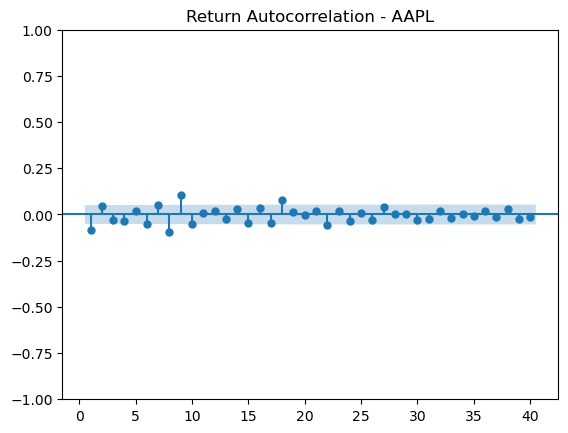

In [6]:
plot_acf(df["Returns"], lags=40, zero=False)
plt.title(f"Return Autocorrelation - {TICKER}")
plt.show()

## 4. Frequency spectrum of returns (FFT)

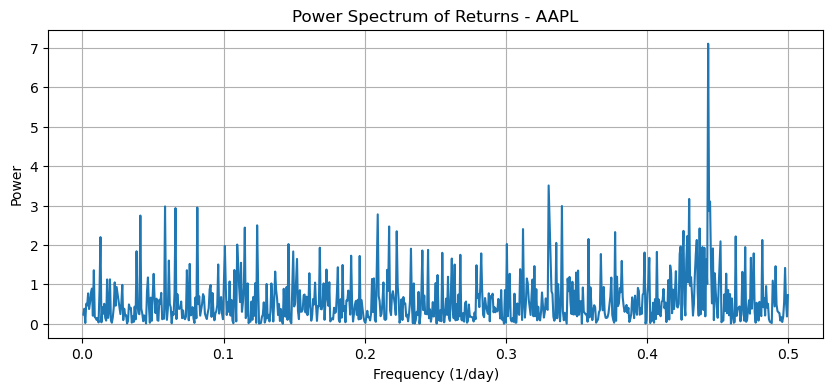

In [7]:
freqs, power = power_spectrum(df["Returns"])

plt.figure(figsize=(10, 4))
plt.plot(freqs, power)
plt.title(f"Power Spectrum of Returns - {TICKER}")
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.grid(True)
plt.show()

## 5. Denoising the price series with a Fourier low-pass filter

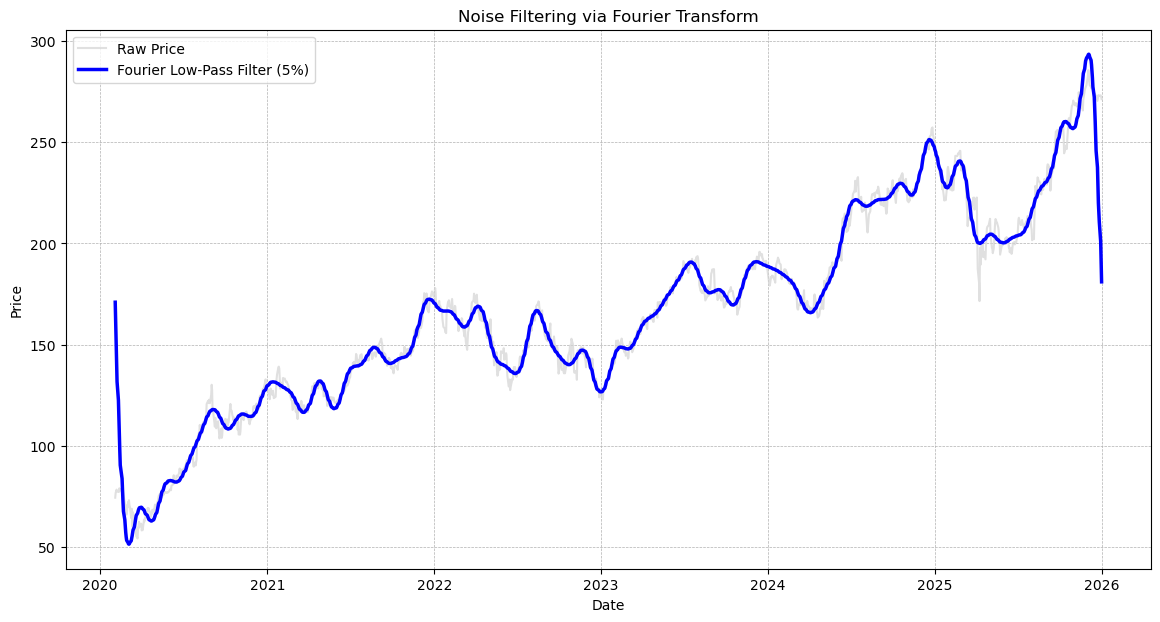

In [8]:
df["Close_Clean"] = low_pass_filter(df["Close"].iloc[:, 0], keep_fraction=0.05)

plt.figure(figsize=(14, 7))
plt.plot(df.index, df["Close"], label="Raw Price", color="lightgray", alpha=0.7)
plt.plot(df.index, df["Close_Clean"], label="Fourier Low-Pass Filter (5%)", color="blue", linewidth=2.5)
plt.title("Noise Filtering via Fourier Transform")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

## 6. Time-frequency analysis (STFT spectrogram)

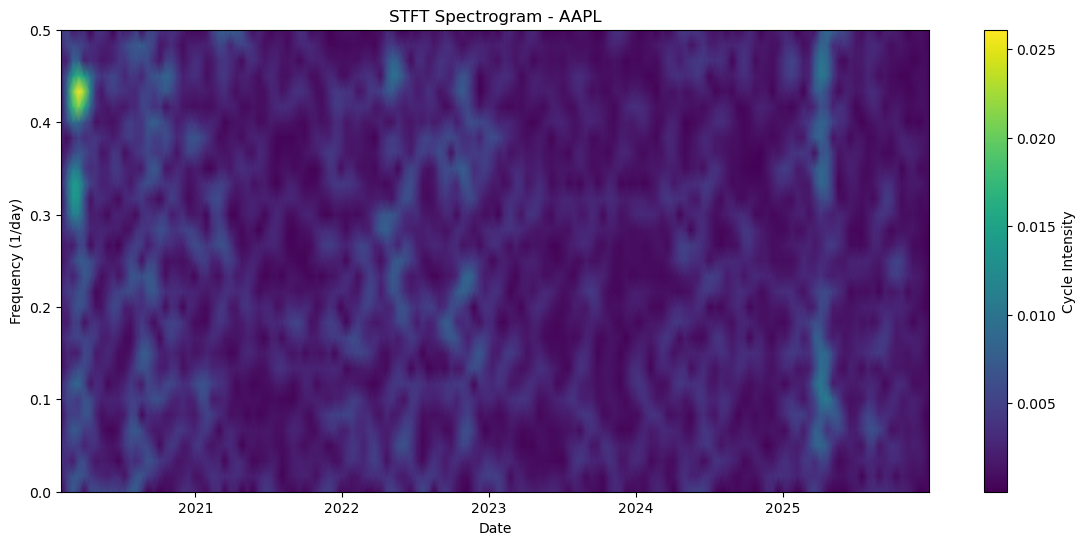

In [9]:
f, dates, power_stft = compute_stft(df["Returns"])

plt.figure(figsize=(14, 6))
plt.pcolormesh(dates, f, power_stft, shading="gouraud", cmap="viridis")
plt.title(f"STFT Spectrogram - {TICKER}")
plt.xlabel("Date")
plt.ylabel("Frequency (1/day)")
plt.colorbar(label="Cycle Intensity")
plt.show()

## 7. Predictive model: XGBoost classifier (next-day direction)

In [11]:
features = feature_matrix(df)
X_train, X_test, y_train, y_test = chronological_split(features)

model = train_model(X_train, y_train)
results = evaluate_model(model, X_test, y_test)

Accuracy: 0.5623
              precision    recall  f1-score   support

           0       0.54      0.31      0.40       137
           1       0.57      0.78      0.66       160

    accuracy                           0.56       297
   macro avg       0.56      0.54      0.53       297
weighted avg       0.56      0.56      0.54       297

